### Legacy vs New Domain creation sanity checks

Author: <b> Sam MacKay </b> </br>

Check confirms (as I already though this was just a sanity check after changes as this was confirmed in tests after the original updates) that domain generation is the same between version.

What is the reason for the disparity in the small box tests then?
Is there a difference in default options or overrides?

Fix this before further investigating of small scale changes, so I can eliminate a potential cause of interference to disparity tests

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(force_device = "cpu")

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /home/administrator/Programs/synthPy/src

Disabling python multi-threading...
Initialising jax...


AssertionError: jax already imported: you must restart your runtime - DO NOT RUN THIS FUNCTION TWICE

In [2]:
import os

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

import legacy.full_solver as fs

importlib.reload(fs)

Setting top level path for imports: /home/administrator/Programs/synthPy/src


<module 'legacy.full_solver' from '/home/administrator/Programs/synthPy/src/legacy/full_solver.py'>

In [3]:
extent_x = 5e-3
extent_y = 5e-3

extent_x_2 = 5e-4
extent_y_2 = 5e-4

extent_z = 10e-3

n_cells = 128

probing_extent = extent_z
probing_direction = 'z'

In [4]:
import jax.numpy as jnp

x = jnp.float32(jnp.linspace(-extent_x / 2, extent_x / 2, n_cells))
y = jnp.float32(jnp.linspace(-extent_y / 2, extent_y / 2, n_cells))
z = jnp.float32(jnp.linspace(-extent_z / 2, extent_z / 2, n_cells))

XX, YY, _ = jnp.meshgrid(x, y, z, indexing = 'ij', copy = True)

ne_0 = 1e24
Ly = 1e-3
s = -2e-3

ne_legacy = 10**(XX/s)*(1+np.cos(2*np.pi*YY/Ly))#*ne_0
ne_legacy_jaxed = 10**(XX/s)*(1+jnp.cos(2*jnp.pi*YY/Ly))#*ne_0

XX = XX.at[:, :, :].set(XX / s)
XX = XX.at[:, :, :].set(10 ** XX)

YY = YY.at[:, :, :].set(YY / Ly)
YY = YY.at[:, :, :].set(jnp.pi * YY)
YY = YY.at[:, :, :].set(2 * YY)
YY = YY.at[:, :, :].set(jnp.cos(YY))
YY = YY.at[:, :, :].set(1 + YY)

ne_new = XX * YY
#ne_new = ne_new.at[:, :, :].set(ne_0 * ne_new)

print("\nLEGACY:\n")
print(ne_legacy)
print("\nLEGACY JAXED:\n")
print(ne_legacy_jaxed)
print("\nNEW:\n")
print(ne_new)


LEGACY:

[[[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [5.4130870e-01 5.4130870e-01 5.4130870e-01 ... 5.4130870e-01
   5.4130870e-01 5.4130870e-01]
  [2.1322856e+00 2.1322856e+00 2.1322856e+00 ... 2.1322856e+00
   2.1322856e+00 2.1322856e+00]
  ...
  [2.1322856e+00 2.1322856e+00 2.1322856e+00 ... 2.1322856e+00
   2.1322856e+00 2.1322856e+00]
  [5.4130870e-01 5.4130870e-01 5.4130870e-01 ... 5.4130870e-01
   5.4130870e-01 5.4130870e-01]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]]

 [[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [5.1732081e-01 5.1732081e-01 5.1732081e-01 ... 5.1732081e-01
   5.1732081e-01 5.1732081e-01]
  [2.0377944e+00 2.0377944e+00 2.0377944e+00 ... 2.0377944e+00
   2.0377944e+00 2.0377944e+00]
  ...
  [2.0377944e+00 2.0377944e+00 2.0377944e+00 ... 2.0377944e+00
   2.0377944e+00 2.0377944e+00]
  [5.1732081e-01 5.1732081

In [6]:
lengths = 2 * np.array([extent_x, extent_y, extent_z])
lengths_2 = 2 * np.array([extent_x_2, extent_y_2, extent_z])

domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, ne_0 = ne_0, Ly = Ly, s = s)
domain_2 = d.ScalarDomain(lengths_2, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, ne_0 = ne_0, Ly = Ly, s = s)

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 5.689472198486328 GB
 - used  : 9.478836059570312 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...
Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 5.661041259765625 GB
 - used  : 9.50728988647461 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


In [8]:
ne_x = np.linspace(-extent_x,extent_x, n_cells)
ne_y = np.linspace(-extent_y,extent_y, n_cells)
ne_z = np.linspace(-extent_z,extent_z, n_cells)

ne_x_2 = np.linspace(-extent_x_2,extent_x_2, n_cells)
ne_y_2 = np.linspace(-extent_y_2,extent_y_2, n_cells)

slab = fs.ScalarDomain(ne_x, ne_y, ne_z, probing_extent)
slab.test_exponential_cos(n_e0 = ne_0, Ly = Ly, s = s)

slab_2 = fs.ScalarDomain(ne_x_2, ne_y_2, ne_z, probing_extent)
slab_2.test_exponential_cos(n_e0 = ne_0, Ly = Ly, s = s)

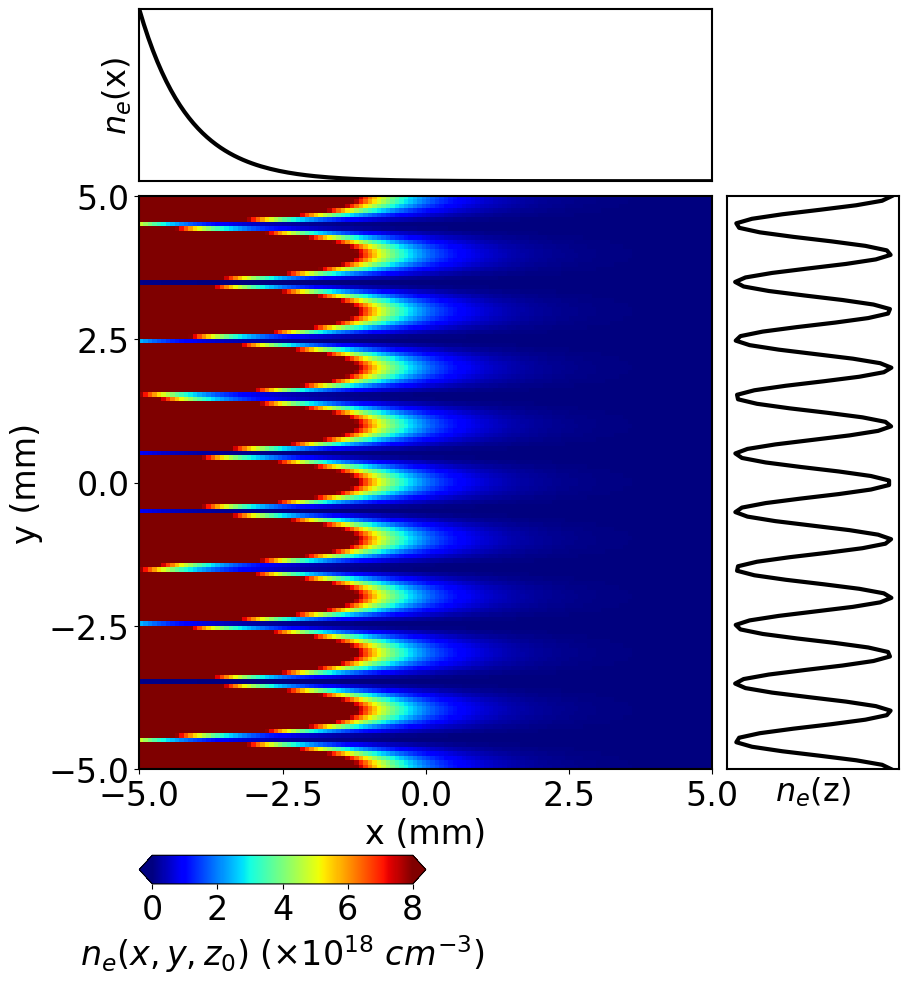

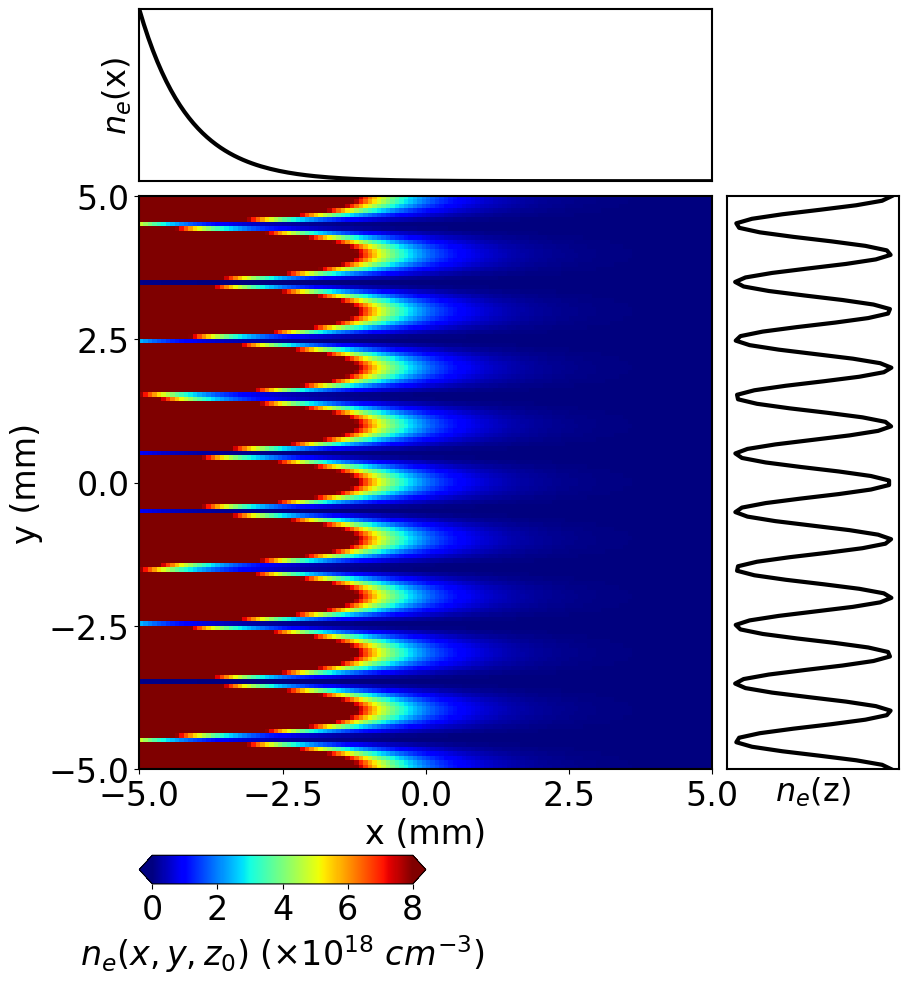

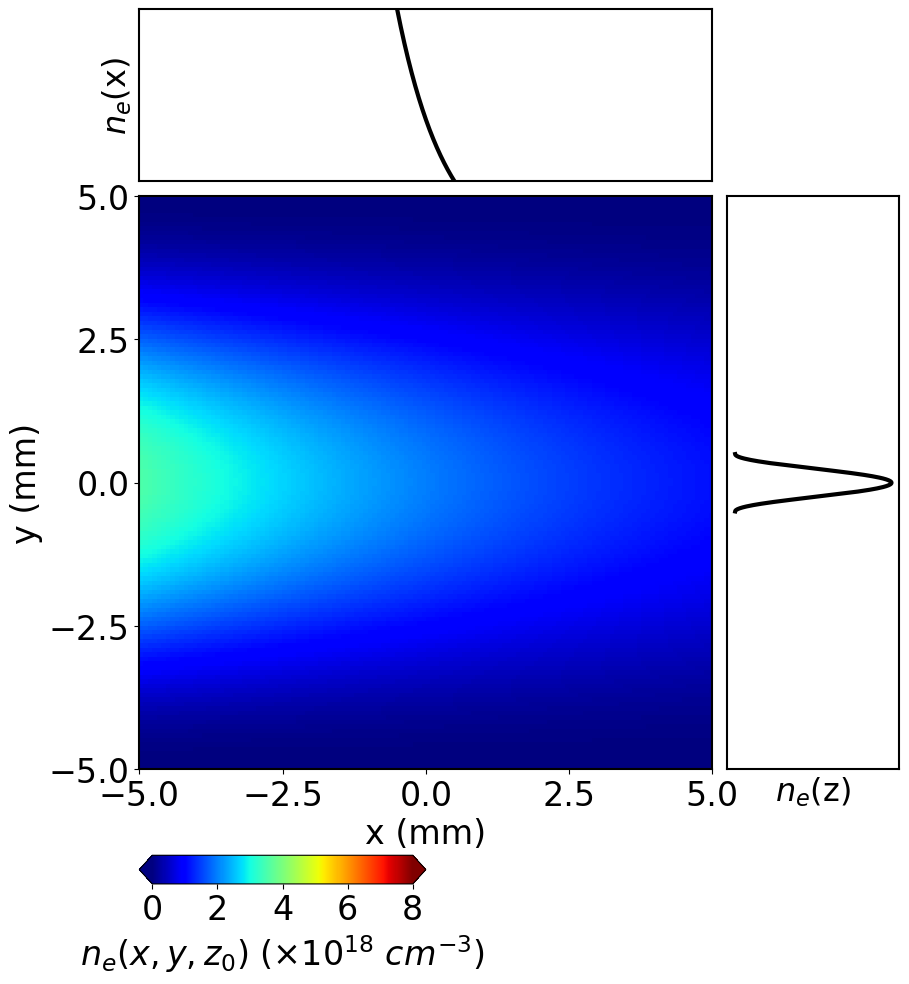

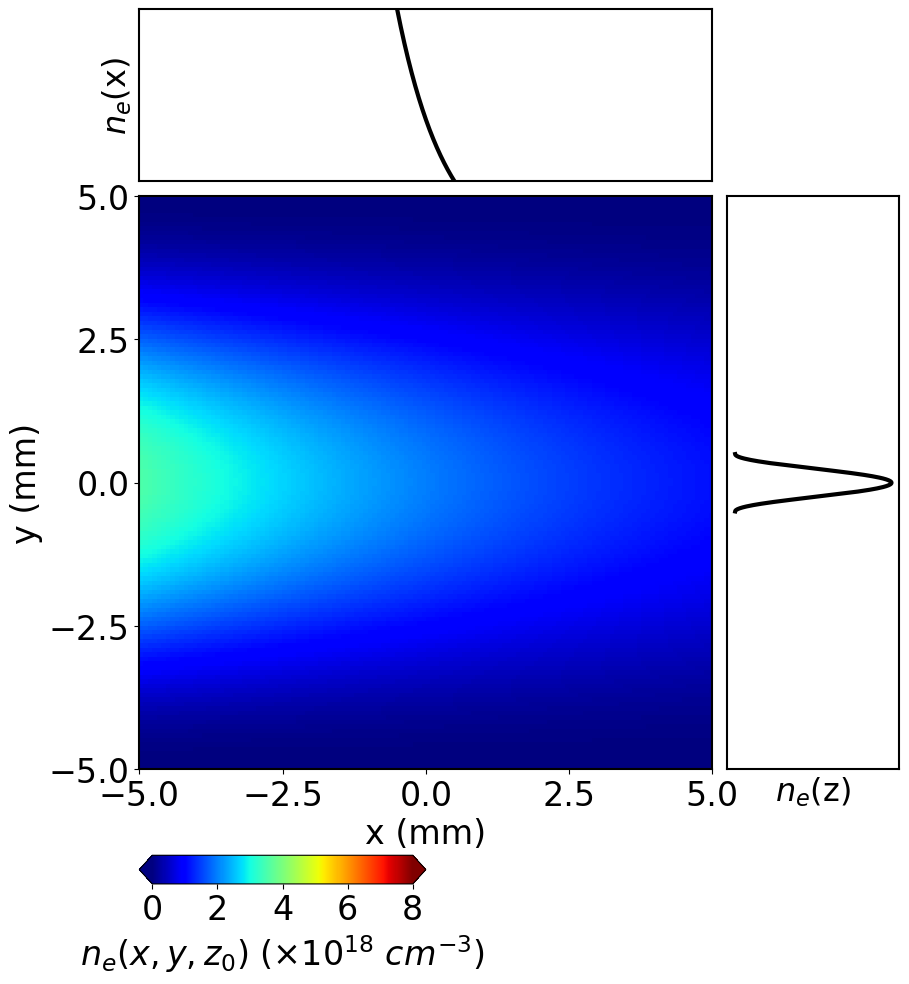

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def graph_domain(domain, *, save = False):
    fig, ax = plt.subplots(figsize = (9.5, 9.5))
    fig.subplots_adjust(.15, .15, .95, .95, hspace = 0.5)

    im = ax.imshow(domain.ne[:,:,0].T/1e24, cmap = 'jet', origin = 'lower', extent = [-5, 5, -5, 5], clim = [0, 8])
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xticks([-5, -2.5, 0, 2.5, 5])
    ax.set_yticks([-5, -2.5, 0, 2.5, 5])

    axins1 = inset_axes(
        ax,
        width="50%",  # width: 50% of parent_bbox width
        height="5%",  # height: 5%
        loc="lower right",
        bbox_to_anchor = (-0.5, -0.2, 1, 1),
        bbox_transform = ax.transAxes,
        borderpad = 0,
    )

    axins1.xaxis.set_ticks_position("bottom")
    cbar = plt.colorbar(im, cax=axins1, ticks=[0, 2, 4, 6, 8], shrink = 0.4, orientation="horizontal", extend='both')
    cbar.set_label(r'$ n_e(x, y, z_0)$ ($\times 10^{18}$ $cm^{-3}$)', fontsize = 24)
    cbar.ax.tick_params(labelsize = 24)

    ax.set_xlabel('x (mm)', fontsize = 24)
    ax.set_ylabel('y (mm)', fontsize = 24)

    divider = make_axes_locatable(ax)
    axvert  = divider.append_axes('right', size = '30%', pad = 0.15)
    axhoriz = divider.append_axes('top',   size = '30%', pad = 0.15)

    profile_vert    =   domain.ne[:, :, 0].T.sum(axis = 0)
    profile_vert    =   (profile_vert - profile_vert.min() ) / (profile_vert.max() - profile_vert.min())
    axhoriz.plot(domain.x, profile_vert, lw = 3, c = 'k', alpha = 1)
    axhoriz.set_xlim(-5e-3, 5e-3)
    axhoriz.set_ylim(0, 1)
    axhoriz.set_ylabel(r'$n_e$(x)', fontsize = 23)

    profile_hor     =   domain.ne[:, :, 0].T.sum(axis = 1)
    profile_hor     =   (profile_hor - profile_hor.min() ) / (profile_hor.max() - profile_hor.min())
    profile_hor_theory  =  profile_hor
    axvert.plot(profile_hor, domain.y, lw = 3, c = 'k', alpha = 1)
    axvert.set_ylim(-5e-3, 5e-3)
    axvert.set_xlabel(r'$n_e$(z)', fontsize = 23)

    ax.tick_params(axis = 'both', labelsize = 24)

    axvert.set_xticks([])
    axhoriz.set_yticks([])
    axvert.set_yticks([])
    axhoriz.set_xticks([])

    for axis in ["top", "bottom", "left", "right"]:
        ax.spines[axis].set_linewidth(1.5)
        axvert.spines[axis].set_linewidth(1.5)
        axhoriz.spines[axis].set_linewidth(1.5)

    # ax.text(4, 4.2, s = 'a)', c = 'w', fontsize = 30)

    # save Figure
    if save:
        from datetime import datetime
        fig.savefig('./analytical 2D electron density distribution - ' + datetime.now().strftime("%Y%m%d-%H%M%S") + '.png', bbox_inches = 'tight', dpi = 600)

graph_domain(domain)
graph_domain(slab)

graph_domain(domain_2)
graph_domain(slab_2)